# 6.2 API Tutorial of Gamma Rhythms

## 1. Background

In order to understand the workflow and initial parameter sets provided with this tutorial, we must first briefly describe prior studies on the mechanistic origin of gamma rhythms, including our prior modeling work that led to the creation of the parameter sets you will work with (Lee and Jones, 2013).

Gamma rhythms can encompass a wide band of frequencies from 30-150 Hz. Here, we will focus on the generation of so called low gamma rhythms in the 30-80 Hz range. It has been well established through experiments and computational modeling that these rhythms can emerge in local spiking networks through interactions of excitatory cell and inhibitory cell interactions, with the period of the oscillation set by the time constant of decay of GABAA-mediated inhibitory currents ((Cardin et al., 2009), (Vierling-Claassen et al., 2010), (Buzsáki and Wang, 2012)), a mechanism that has been referred to as pyramidal-interneuronal gamma (PING). In normal regimes, the decay time constant of GABAA-mediated synapses (~25 ms) bounds oscillations to the low gamma frequency band (~40 Hz).

In general, PING rhythms are initiated by "excitation" to the excitatory (E) cells that causes spiking, which in turn synaptically activates a spiking population of inhibitory (I) cells. In turn, these I cells inhibit the E cells, preventing further E cell activity until the E cells can overcome the effects of the inhibition (~25 ms later). The pattern is repeated, creating a gamma frequency oscillation (~40 Hz, 40 spikes/second). This general principle is schematically described in Figure 1 below. The frequency of the rhythm is paced by this time constant of decay of inhibition, which is mediated by strong GABA-A currents, as well as the excitability of the E cells (if the E cells are very excitable, they can fire before the inhibition has completely worn off, and the oscillation will be faster).

![**Figure 1**: Schematic illustration showing the PING rhythm mechanism with excitatory pyramidal neurons firing first, followed by inhibitory interneurons, with timing controlled by GABA-A decay, adapted from several figures in the papers of the Background section](https://raw.githubusercontent.com/jonescompneurolab/jones-website/master/images/textbook/content/07_gamma/gamma_fig_01.png)

In this tutorial, we will explore the generation of PING rhythms in the HNN model. We will provide example parameter files and walk through simulations that generate gamma activity in both Layers 2/3 and Layer 5, as in (Lee and Jones, 2013). This tutorial relies on a different type of exogenous drive to "activate" the local network than the other tutorials. Here, the necessary excitation to generate spiking in the pyramidal neurons that initiates the rhythm (see PING description above) is provided by a continuous train of action potentials with a Poisson distribution that activates post-synaptic excitatory AMPA synapses on the pyramidal neurons. This Poisson drive causes the pyramidal neurons to fire, dependent on the chosen conductance of the AMPA currents. The inhibition in the network is strong enough to overcome the Poisson drive and entrain the network spiking into a gamma frequency rhythm.

Of note, gamma rhythms can be generated by circuit mechanisms other than PING, including subthreshold rhythmic exogenous drive. The publication (Lee and Jones, 2013) examined various mechanisms of generation of gamma activity and described ways to distinguish the mechanisms of generation based on features of current dipole signal. After completing this tutorial, we encourage you to explore alternate mechanisms of gamma generation and to compare to your own gamma data.

**Please note that the configuration we use in this Tutorial is for illustrative purposes only. In this network, Layer 2/3 and Layer 5 are not connected to each other, and additionally, Layer 2/3 and Layer 5 pyramidal cells are not connected to other cells of the same time. Therefore, *the network used is not biologically realistic*.**

## 2. Setup and Downloading HNN Parameter Set Files

Before we do anything else, we will import the python libraries that we need:


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import matplotlib.pyplot as plt

import hnn_core
from hnn_core import read_network_configuration, simulate_dipole
from hnn_core.network import pick_connection
from hnn_core.viz import plot_dipole

--No graphics will be displayed.


Throughout this tutorial, we will be using several different HNN parameter set files. These files are not included in the HNN installation, but instead must be downloaded separately. These four files are located at [https://github.com/jonescompneurolab/hnn-data/tree/main/workshops/2025-04-09-HNN-online_workshop/gamma_gui_walkthrough](https://github.com/jonescompneurolab/hnn-data/tree/main/workshops/2025-04-09-HNN-online_workshop/gamma_gui_walkthrough) .

In [2]:
# If you have already downloaded the gamma network files
# to your own directory, then please change this path to
# point to where you downloaded the files, and you can skip
# the next code cell.
local_gamma_network_files_directory = Path.cwd() / "gamma_network_files"

In [3]:
# Only run this if you have NOT already downloaded the gamma
# network files, since it will save a copy of the files
Path.mkdir(local_gamma_network_files_directory, exist_ok=True)
data_directory_url = "https://raw.githubusercontent.com/jonescompneurolab/hnn-data/main/workshops/2025-04-09-HNN-online_workshop/gamma_gui_walkthrough/"
files_to_download = [
    "gamma_L5weak_L2weak.json",
    "gamma_L5weak_only.json",
    "gamma_L5ping_L2ping.json",
    "gamma_rhythmic_drive.json",
]
for file_name in files_to_download:
    urlretrieve(
        data_directory_url + file_name,
        local_gamma_network_files_directory / file_name,
        )


## 3. Setting Initial Run Parameters

Before running any simulations, we set the values that are shared by every simulation in this notebook. These are the API equivalents of the changes made in the GUI's `Simulation` tab:

- `tstop` is set to `300` ms, instead of the GUI default of `170` ms.
- Dipole smoothing is left off. In the GUI, you must change `Dipole Smoothing` from `30` to `0` so that higher-frequency content like gamma can be detected and analyzed correctly. In the API, no smoothing is applied unless you explicitly call `Dipole.smooth()`, so there is nothing to change.
- `scaling_factor` is `3000`, which is the same dipole scaling the GUI applies by default.
- Using multiple cores greatly increases simulation speed, equivalent to the `Cores` textbox in the GUI. Below, we detect whether MPI is available and, if so, use one process per physical core minus one.


In [4]:
# --- Settings shared by every simulation in this notebook ---
tstop = 300.0             # ms; simulation duration
tmin = 0.0                # ms; start time used for plots and spectral
                          # analysis. Raise this (e.g. to 50.0) to omit the
                          # initial transient of a simulation.
trial_idx = 0             # index of the single trial run in each simulation
scaling_factor = 3000     # same dipole scaling the GUI applies by default
freqs = np.arange(10., 100., 1.)   # frequency range (Hz) for spectrogram plots

# --- Parallel backend ---
# HNN-Core's "MPIBackend" gives the largest speed-up, but requires both the `mpi4py`
# Python package and an MPI installation. If either is missing, we fall back to Joblib,
# which parallelizes *across* trials only, and therefore does not speed up the
# single-trial simulations we run below.
#
# We offer complete guides to installing MPI with HNN-Core at
# https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html
# and if you have any installation issues, feel free to reach out to us on our
# Discussion Board at https://github.com/jonescompneurolab/hnn-core/discussions where we
# can help you troubleshoot.
try:
    import mpi4py  # noqa: F401
    import psutil
    n_procs = psutil.cpu_count(logical=False) - 1
    use_mpi = True
    print('Using MPIBackend with %d processes' % n_procs)
    from hnn_core.parallel_backends import MPIBackend
except ImportError:
    n_procs = 1
    use_mpi = False
    print('MPI is not available; using JoblibBackend instead')
    from hnn_core.parallel_backends import JoblibBackend

Using MPIBackend with 11 processes


## 4. Load/view Parameters of the Network Structure

In the GUI, the network structure and the external drives are loaded separately, in the `Network` and `External drives` tabs respectively. With the API, we only need a single call to `read_network_configuration()` to load both at once.

We can easily inspect all connections of the network by printing the `Network` attribute for connectivity. This will give us information similar to the GUI list of each connection/drive. 

**Note that, since this tutorial is using a special case of the network, Layers 2/3 and 5 are not connected to each other. Additionally, note that there are no active connections between L2/3 pyramidal cells to other L2/3 pyramidal cells, and L5 pyramidal cells are disconnected from each other as well.** Since drives are considered part of the connectivity of the network, drive connections are also shown by this command.

In [5]:
# Load the first gamma network parameter file.
net = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_L5weak_L2weak.json'
    )

# Print the network connectivity to console
net.connectivity

[L2_pyramidal -> L2_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'nmda'
 weight: 0.0; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L2_pyramidal -> L2_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'ampa'
 weight: 0.0; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L5_pyramidal -> L5_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'nmda'
 weight: 0.0; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L5_pyramidal -> L5_pyramidal
 cell counts: 100 srcs, 100 targets
 connection probability: 1.0 
 loc: 'proximal'; receptor: 'ampa'
 weight: 0.0; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
  ,
 L2_basket -> L2_pyramidal
 cell counts: 35 srcs, 100 targets
 connection probability: 1.0 
 loc: 'soma'; receptor: 'gabaa'
 weight: 0.007; delay: 1.0; lamtha: 50.0threshold: 0.0gain: 1.0
  ,
 L2_basket -> L2_pyramid

## 5. Load/view Parameters of the External Drive

We can also see all of the drives easily by printing the corresponding `Network` attribute. These parameters control a Poisson process of excitatory (AMPAergic) synaptic input spikes, which "activates" the network. As discussed in the Background above, these driving inputs are delivered to the somas of the pyramidal neurons in Layer 2/3 and Layer 5, which initiates the PING rhythm.

In [6]:
net.external_drives

{'extpois': <External drive 'extpois'
 drive class: poisson
 target location: proximal
 target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
 number of drive cells: 270
 cell-specific: True
 dynamic parameters:
 	tstart: 0
 	tstop: 300.0
 	rate_constant: {'L2_basket': 1, 'L2_pyramidal': 140.0, 'L5_basket': 1, 'L5_pyramidal': 40.0}>}

## 6. Run the Simulation and Visualize the Dipole and Spectrogram

Now that we have set our simulation parameters and loaded both our network configuration and external drive, we are ready to run our first simulation. Let's first define a small `run_simulation()` helper here, since every simulation in this notebook is run and scaled in exactly the same way.

In [7]:
def run_simulation(net, tstop=tstop):
    """Run a simulation (single trial) and return its scaled aggregate dipole.

    This is the API equivalent of clicking `Run` in the GUI's `Simulation`
    tab. Note that, unlike the GUI, there is no need to give each
    simulation a unique name: we simply assign each result to its own
    Python variable.
    """
    backend = MPIBackend(n_procs=n_procs) if use_mpi else JoblibBackend(n_jobs=1)
    with backend:
        dpl = simulate_dipole(net, tstop=tstop)[trial_idx]
    return dpl.scale(scaling_factor)

Now we will run the actual simulation. Then we will show a histogram displaying:

1. The Poisson drive to the excitatory cells on the top panel, which will display no clear rhythmicity. 
2. The simulated dipole on the bottom panel, which *will* display some obvious rhythmicity in the signal!

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

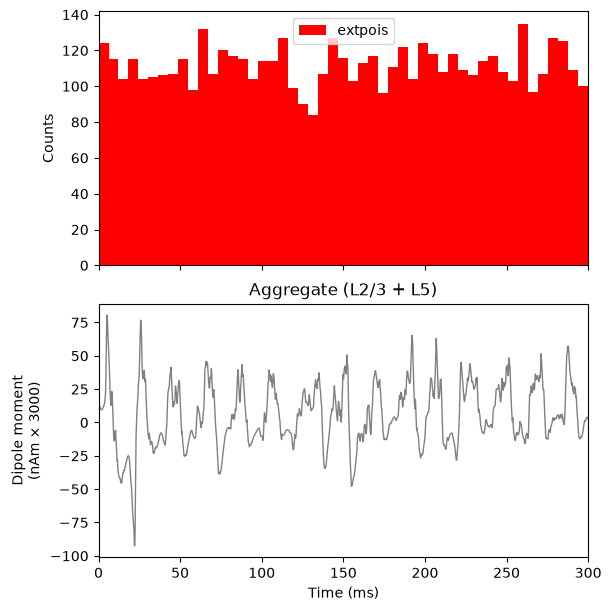

In [8]:
# -----------------------------------------------------------------------
# Run the first simulation and visualize the external input and dipole
# -----------------------------------------------------------------------
dpl = run_simulation(net)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6), constrained_layout=True)

# Top panel: external drive spike-time histogram (the single 'extpois' drive)
net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['extpois'], show=False)

# Bottom panel: aggregate dipole waveform
plot_dipole(dpl, ax=axes[1], layer='agg', show=False)

plt.show()

 The Poisson drive provided causes pyramidal neurons to fire, which in turn cause the inhibitory neurons to fire. Feedback inhibition from the interneurons to the pyramidal neurons generates a regular gamma rhythm via the PING mechanism described above (see Background above), which we can see in the rhythmicity of the simulated dipole. The sharp downward deflections in the dipole are reflective of the strong inhibition onto the pyramidal neuron somas, which pulls current flow down the dendrites.
 
 To confirm that the rhythmicity is in the gamma frequency range (~55 Hz), let’s plot a spectrogram of the net current dipole:

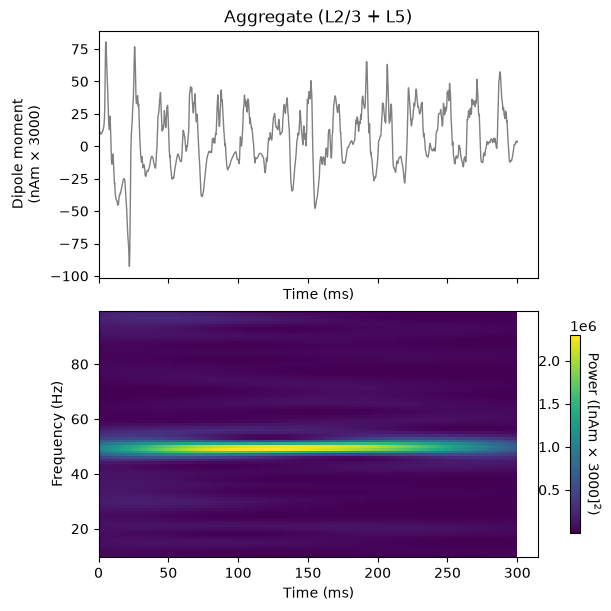

In [9]:
# -----------------------------------------------------------------------
# Reproduce the GUI's `Dipole-Spectrogram (2x1)` visualization template:
# the raw dipole waveform on top, and a Morlet time-frequency
# representation below.
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6), constrained_layout=True)

dpl.plot(tmin=tmin, ax=axes[0], layer='agg', show=False)
axes[0].set_title('Aggregate (L2/3 + L5)')

dpl.plot_tfr_morlet(
    freqs,
    n_cycles=freqs / 2.0,
    tmin=tmin,
    layer='agg',
    ax=axes[1],
    show=False,
    colormap='viridis'
)

plt.show()

## 7. Calculating and Viewing Spiking Activity and Power Spectral Density (PSD)

Next, let's look at the spiking activity generated by the different neuron populations in the network, and at the power spectral density (PSD) of the current dipole signal (i.e. the average of the spectrogram across time).

In the rastergram below, notice that the excitatory pyramidal neurons in each layer fire *before* the inhibitory basket cells in each layer. The pyramidal neuron firing drives the basket cells to fire, and the basket cells are highly synchronous due to the strong inhibitory-to-inhibitory connections. The basket cells then prevent the pyramidal neurons from firing for ~25 ms, generating the PING rhythm. The pyramidal neurons fire periodically, but with lower synchrony due to the Poisson drive, which randomizes spike times across the population. This type of dispersed pyramidal neuron firing is considered **"weak" PING** — hence the "weak" in the name of the configuration file.

If we examine how the PSDs are different between Layer2/3 and Layer 5 in the second figure, notice that the power in the gamma band is much smaller in Layer 2/3 than in Layer 5 (pay attention to the scale of the y-axes). This reflects, in part, the fact that Layer 2/3 pyramidal neurons are shorter than Layer 5 ones, and hence produce smaller current dipole moments that can be masked by activity in Layer 5 (see (Lee and Jones 2013) for further discussion).

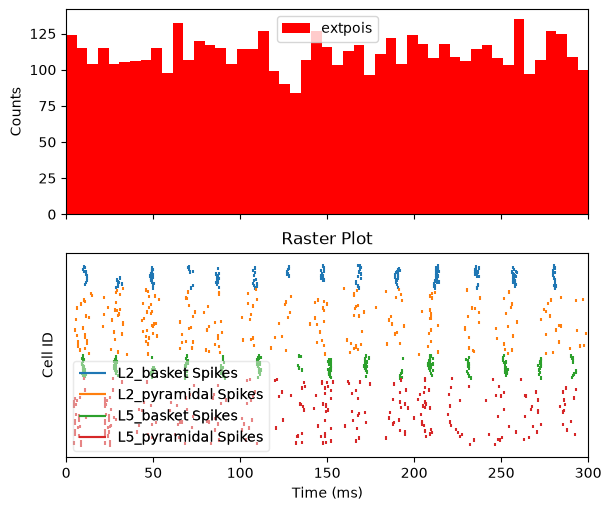

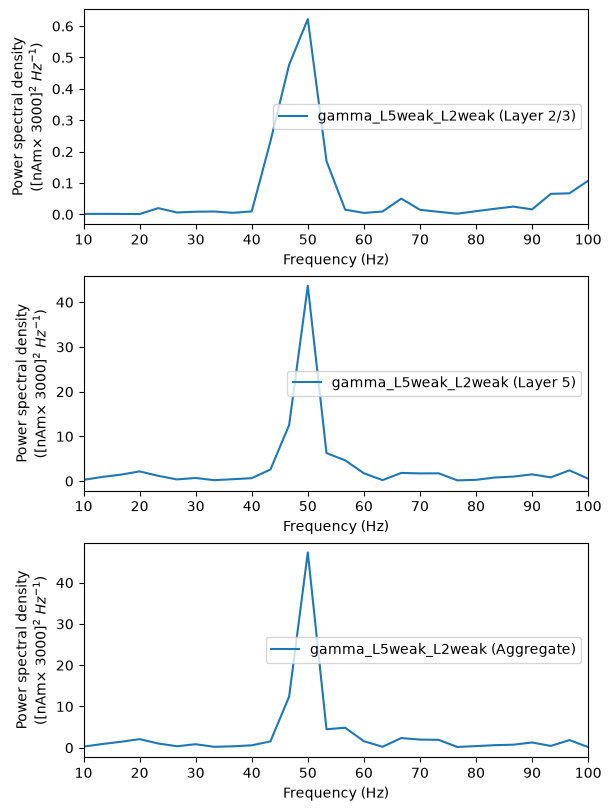

In [10]:
# -----------------------------------------------------------------------
# Spiking activity: the GUI's `Drive-Spikes (2x1)` visualization template,
# with the drive histogram on top and the spike rastergram below.
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 5), constrained_layout=True)
net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['extpois'], show=False)
net.cell_response.plot_spikes_raster(ax=axes[1], show=False)
plt.show()

# -----------------------------------------------------------------------
# Power spectral density: the GUI's `PSD Layers (3x1)` visualization
# template, with one panel per layer plus the aggregate. Each panel has
# its own y-axis scale.
# -----------------------------------------------------------------------
layer_labels = [('L2', 'Layer 2/3'), ('L5', 'Layer 5'), ('agg', 'Aggregate')]
fig, axes = plt.subplots(3, 1, figsize=(6, 8), constrained_layout=True)
for ax, (layer, layer_label) in zip(axes, layer_labels):
    dpl.plot_psd(fmin=10., fmax=100., tmin=tmin, layer=layer,
                 label='gamma_L5weak_L2weak (%s)' % layer_label,
                 ax=ax, show=False)
    ax.legend()
plt.show()

### Packaging the GUI's figures as reusable functions

By hand, we have now made all four of the figures that we will want for every remaining simulation in this tutorial: the drive histogram and dipole shown after clicking `Run` in the GUI, plus the GUI's `Dipole-Spectrogram (2x1)`, `Drive-Spikes (2x1)`, and `PSD Layers (3x1)` visualization templates.

Rather than repeat all of that code for each simulation, let's package each figure into a function. Each function below is the API equivalent of one GUI visualization template.

In [11]:
LAYER_LABELS = [('L2', 'Layer 2/3'), ('L5', 'Layer 5'), ('agg', 'Aggregate')]


def _drive_names(net):
    """Names of the spiking drives of a network, if it has any.

    Some networks below are driven only by a tonic applied current, and
    therefore have no spiking drive to make a histogram of.
    """
    return list(net.external_drives.keys())


def _distal_drive_names(net, drive_names):
    """Names of the given drives whose target location is 'distal'.

    Distal drives push current up the dendrites rather than down, so we
    invert their histogram bars to visually distinguish them from
    proximal/somatic drives.
    """
    return [name for name in drive_names
            if net.external_drives[name]['location'] == 'distal']


def plot_drive_and_dipole(net, dpl, sim_name, tmin=tmin, tmax=None):
    """Drive histogram + dipole: the GUI's `Simulation` tab output."""
    drive_names = _drive_names(net)
    if len(drive_names) == 0:
        fig, ax = plt.subplots(1, 1, figsize=(6, 3.5), constrained_layout=True)
        axes = [ax]
    else:
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6),
                                 constrained_layout=True)
        net.cell_response.plot_spikes_hist(
            ax=axes[0], spike_types=drive_names,
            invert_spike_types=_distal_drive_names(net, drive_names),
            show=False)
    dpl.plot(tmin=tmin, tmax=tmax, layer='agg', ax=axes[-1], show=False)
    fig.suptitle(sim_name)
    plt.show()


def plot_dipole_and_spectrogram(dpl, sim_name, tmin=tmin, tmax=None):
    """The GUI's `Dipole-Spectrogram (2x1)` visualization template."""
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6),
                             constrained_layout=True)
    dpl.plot(tmin=tmin, tmax=tmax, layer='agg', ax=axes[0], show=False)
    axes[0].set_title('Aggregate (L2/3 + L5)')
    dpl.plot_tfr_morlet(freqs, n_cycles=freqs / 2.0, tmin=tmin, tmax=tmax,
                        layer='agg', ax=axes[1], show=False, colormap='viridis')
    fig.suptitle(sim_name)
    plt.show()


def plot_drive_and_spikes(net, sim_name):
    """The GUI's `Drive-Spikes (2x1)` visualization template."""
    drive_names = _drive_names(net)
    if len(drive_names) == 0:
        fig, ax = plt.subplots(1, 1, figsize=(6, 3.5), constrained_layout=True)
        axes = [ax]
    else:
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6),
                                 constrained_layout=True)
        net.cell_response.plot_spikes_hist(
            ax=axes[0], spike_types=drive_names,
            invert_spike_types=_distal_drive_names(net, drive_names),
            show=False)
    # trial_idx is a global variable defined at the top of this notebook to be the first trial, i.e. index 0
    net.cell_response.plot_spikes_raster(trial_idx=trial_idx, ax=axes[-1],
                                         show=False)
    fig.suptitle(sim_name)
    plt.show()


def plot_psd_by_layer(dpl, sim_name, tmin=tmin, tmax=None, fmin=10., fmax=100.):
    """The GUI's `PSD Layers (3x1)` visualization template."""
    fig, axes = plt.subplots(3, 1, figsize=(6, 8), constrained_layout=True)
    for ax, (layer, layer_label) in zip(axes, LAYER_LABELS):
        dpl.plot_psd(fmin=fmin, fmax=fmax, tmin=tmin, tmax=tmax, layer=layer,
                     label='%s (%s)' % (sim_name, layer_label), ax=ax,
                     show=False)
        ax.legend()
    fig.suptitle(sim_name)
    plt.show()

## 8. Adjusting Parameters

In the following sections, we explore the impacts of two key parameters controlling gamma rhythmicity: **cell excitability** and **network connectivity**. Cell excitability can be adjusted in many ways, including changes to the intrinsic properties of a neuron (e.g. membrane resting potential) or the influence of external factors such as noisy background inputs or neuromodulation. Network connectivity can be adjusted by changing parameters such as the synaptic connection strengths between cells or the time constants of synaptic activation.

### 8.1 Restricting Spiking to L5

First, in order to simplify our investigation, we load a network configuration that retains connectivity ONLY in Layer 5 (all inputs and connectivity in Layer 2/3 become zero). In the GUI, this requires loading `gamma_L5weak_only.json` twice, once in the `Network` tab and once in the `External drives` tab. In contrast, with the API, a single call to `read_network_configuration()` loads both the local connectivity and the drives.

Let's load the network configuration and run the simulation:


In [12]:
# This `net_l5` configuration is the baseline that sections 8.2 - 8.6
# each modify in a different way.
net_l5 = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_L5weak_only.json')

dpl_l5 = run_simulation(net_l5)

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

Now let's plot the results using our reusable functions from above.

The simulation yields a gamma rhythm that looks similar to the one we observed previously, but the spike raster and PSDs now show activity from **only** Layer 5. Notice the weak PING rhythm in Layer 5, consisting of weakly synchronous pyramidal neuron firing followed by synchronous inhibitory neuron firing. The synchronous inhibitory spiking gates the network dipole rhythm to ~55 Hz.

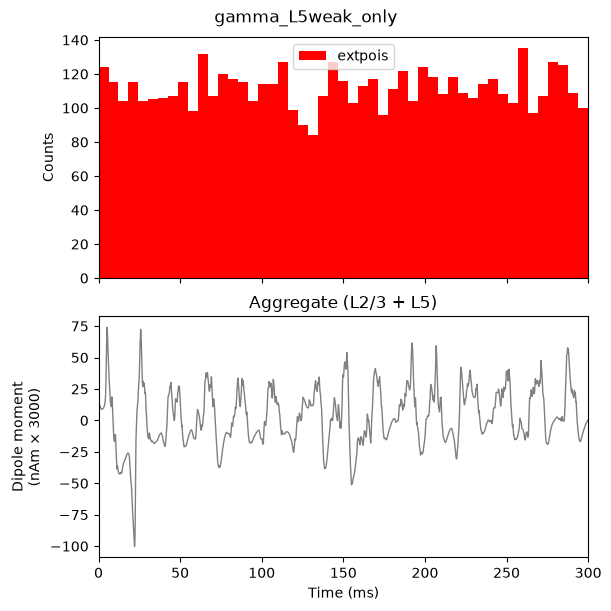

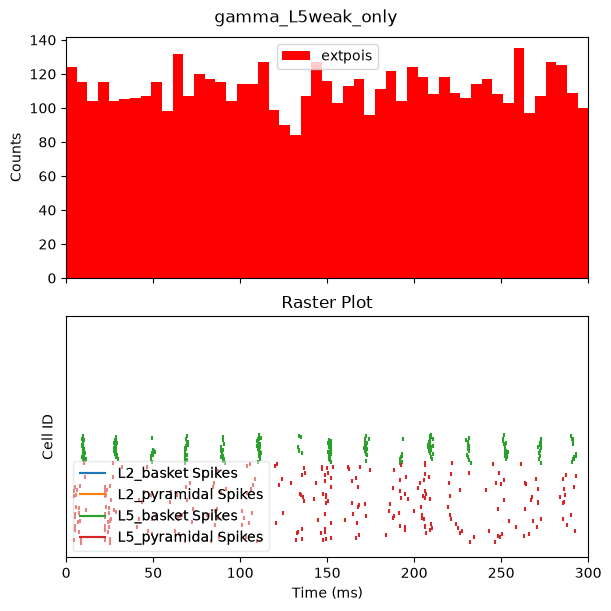

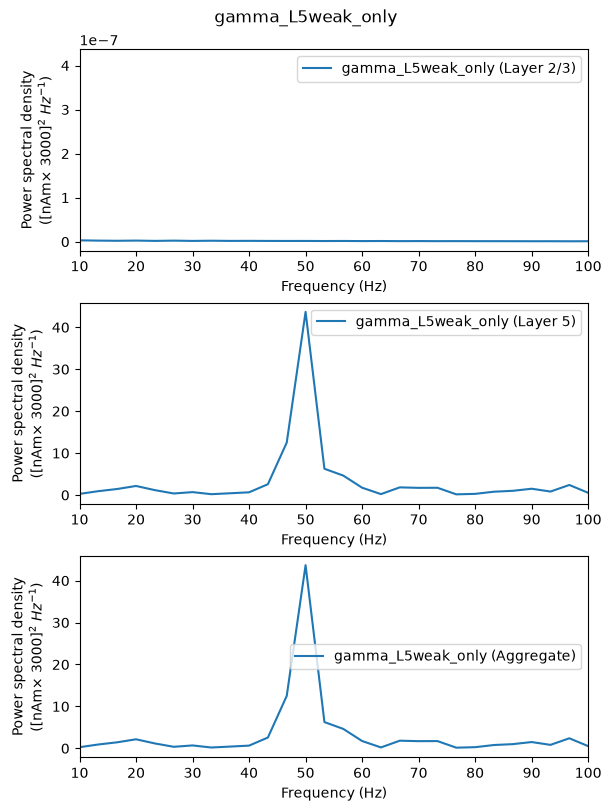

In [13]:
plot_drive_and_dipole(net_l5, dpl_l5, 'gamma_L5weak_only')
plot_drive_and_spikes(net_l5, 'gamma_L5weak_only')
plot_psd_by_layer(dpl_l5, 'gamma_L5weak_only')

### 8.2 Increasing Cell Excitability via a Weak Tonic Input

To examine the impact of **cell excitability** on gamma expression, we increase the excitability of the Layer 5 pyramidal neurons by adding a "tonic applied current" of 2 nA. Biologically, this could represent a change in neuromodulatory influence on the network. In the GUI, this means adding a `Tonic` drive in the `External drives` tab and setting its `Amplitude (nA)` for `L5_pyramidal` to `2`; with the API, we call `Network.add_tonic_bias()`.

In [14]:
net_tonic_weak = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_L5weak_only.json')
net_tonic_weak.add_tonic_bias(cell_type='L5_pyramidal', amplitude=2.)

Next, we run and plot the simulation.

When examining the output, note that the network takes longer to stabilize due to the initial impact of the tonic current. From about 50 ms onward, the initial impact has subsided and the influence of both the tonic and Poisson drives is more evident.

Comparing the results below to those of the prior Section 8.1, the pyramidal neuron spiking is visibly more synchronous, though some noise from the Poisson drive is still present, and there is an overall increase in the number of spikes. Meanwhile, the frequency of the gamma rhythm has *decreased* slightly, from approximately ~55 Hz to ~48 Hz.

In other words: while increasing excitability causes the pyramidal cells to fire more synchronously, interpreting the competing effects of excitation and inhibition is not always straightforward. The more synchronous pyramidal firing is not strong enough to induce a "strong" PING in the local network, since there is still apparent noise from the Poisson input. However, the overall **increase** in the pyramidal neuron firing rate appears to more strongly recruit the inhibitory interneurons, which has the net effect of slightly **decreasing** the frequency of the observed gamma rhythm.

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

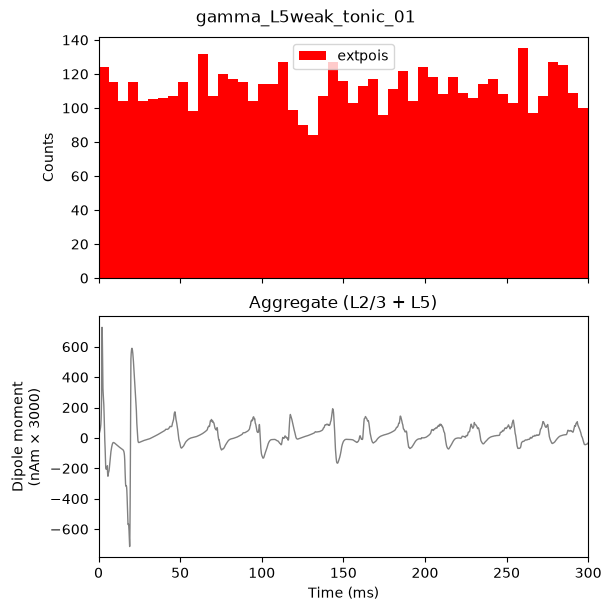

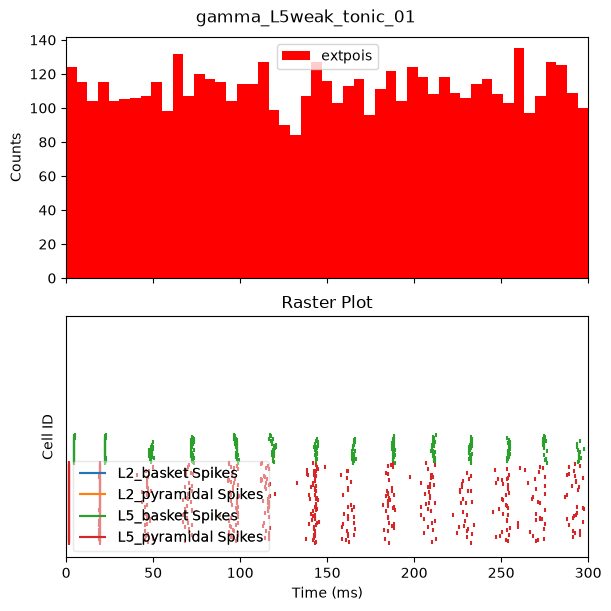

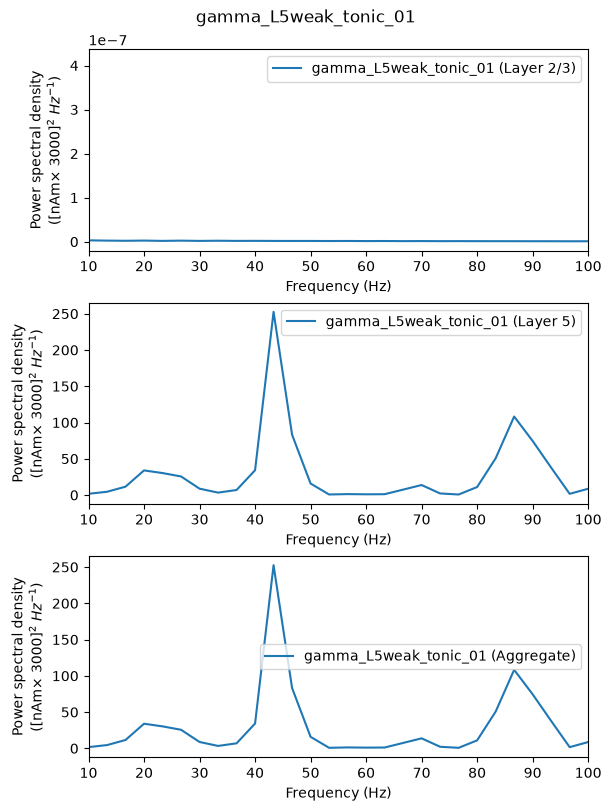

In [15]:
dpl_tonic_weak = run_simulation(net_tonic_weak)

plot_drive_and_dipole(net_tonic_weak, dpl_tonic_weak, 'gamma_L5weak_tonic_01')
plot_drive_and_spikes(net_tonic_weak, 'gamma_L5weak_tonic_01')
plot_psd_by_layer(dpl_tonic_weak, 'gamma_L5weak_tonic_01')

### 8.3 Increasing Tonic Input

Next, let's continue examining the role of cell excitability on the gamma rhythm by further increasing the tonic drive we added, from 2 nA to 6 nA.

In [16]:
net_tonic_strong = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_L5weak_only.json')
net_tonic_strong.add_tonic_bias(cell_type='L5_pyramidal', amplitude=6.)

Compared to the previous simulation, this one is *significantly* more synchronous. However, for the same reason as before (more pyramidal firing causing greater recruitment of the inhibitory neurons), the frequency is even lower than before, decreasing from approximately ~48 Hz to ~44 Hz.

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

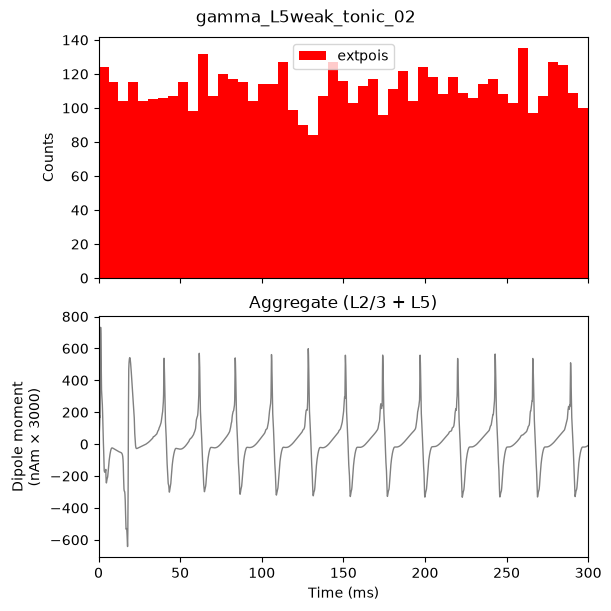

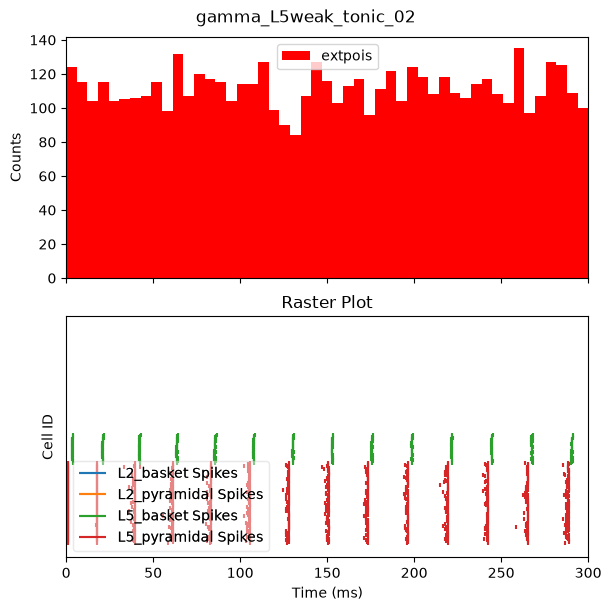

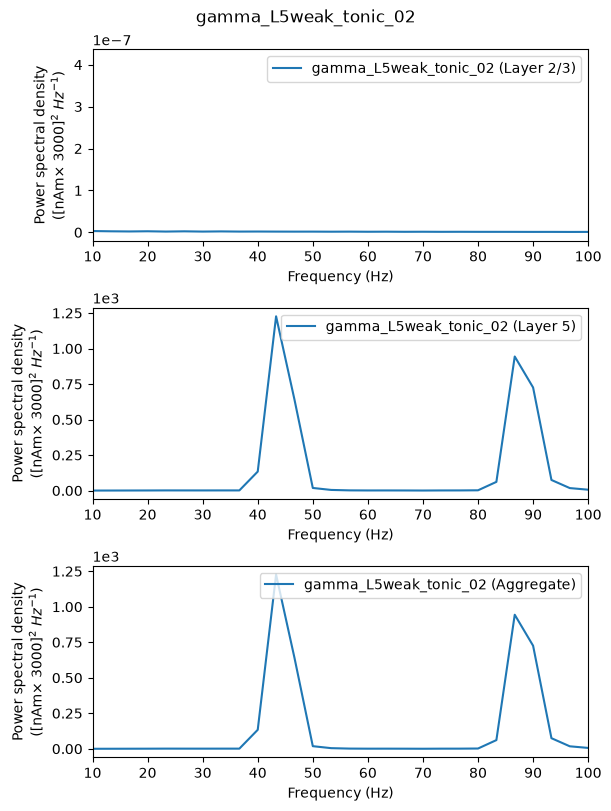

In [17]:
dpl_tonic_strong = run_simulation(net_tonic_strong)

plot_drive_and_dipole(net_tonic_strong, dpl_tonic_strong, 'gamma_L5weak_tonic_02')
plot_drive_and_spikes(net_tonic_strong, 'gamma_L5weak_tonic_02')
plot_psd_by_layer(dpl_tonic_strong, 'gamma_L5weak_tonic_02')

### 8.4 Weakening the Excitatory Connections

We'll now explore the impact of adjusting **synaptic connectivity** parameters in the network. Keeping the 6 nA tonic drive from the previous section, we decrease the AMPA weight of the `L5_pyramidal` to `L5_basket` connection by a factor of 10, from `0.00091` to `0.000091`. In the GUI, this is done in the `Connectivity` sub-tab of the `Network` tab; with the API, we locate the connection with `pick_connection()` and then edit its weight directly.

In [18]:
# Note that `Network.connectivity` is a list of dictionaries, and that
# `pick_connection()` returns the *indices* of the connections matching
# the criteria we give it. The synaptic weight of a connection lives in
# its `nc_dict` under the key `A_weight`.
net_weak_conn = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_L5weak_only.json')
net_weak_conn.add_tonic_bias(cell_type='L5_pyramidal', amplitude=6.)

conn_indices = pick_connection(net_weak_conn, src_gids='L5_pyramidal',
                               target_gids='L5_basket', receptor='ampa')
for idx in conn_indices:
    print('original weight:', net_weak_conn.connectivity[idx]['nc_dict']['A_weight'])
    net_weak_conn.connectivity[idx]['nc_dict']['A_weight'] *= 0.1
    print('new weight:     ', net_weak_conn.connectivity[idx]['nc_dict']['A_weight'])


original weight: 0.00091
new weight:      9.1e-05


Now let's simulate and evaluate the results. You may be thinking something like *"The last several simulations gradually increased pyramidal firing, which caused increased inhibitory cell firing, which then caused the frequency to go down. If we're weakening the E-to-I connection in this simulation, then the frequency should increase."* However! Part of what makes science interesting is the unexpected and counter-intuitive. Below, you can clearly see that the gamma rhythm has continued to **decrease**, from ~44 Hz to ~40 Hz. This slowing is still due to the fact that the excitatory-to-inhibitory connection was greatly weakened: it now takes longer for the basket cells to respond to the excitation. Notice how there is an increase in the "lag" in the response of the inhibitory cells compared to the previous simulation.

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

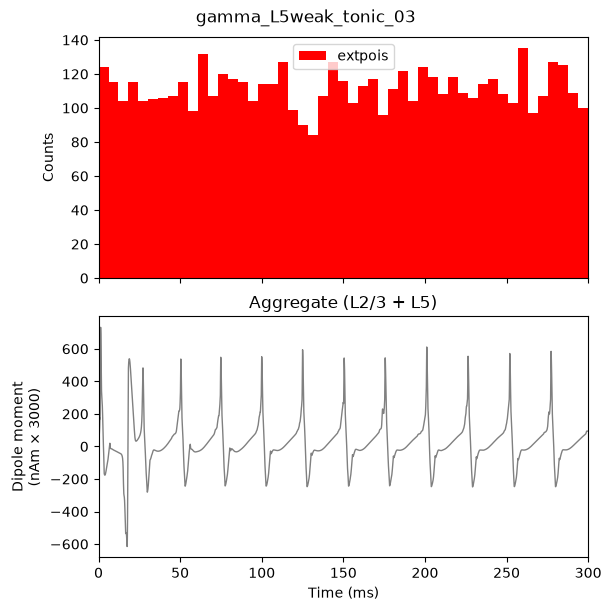

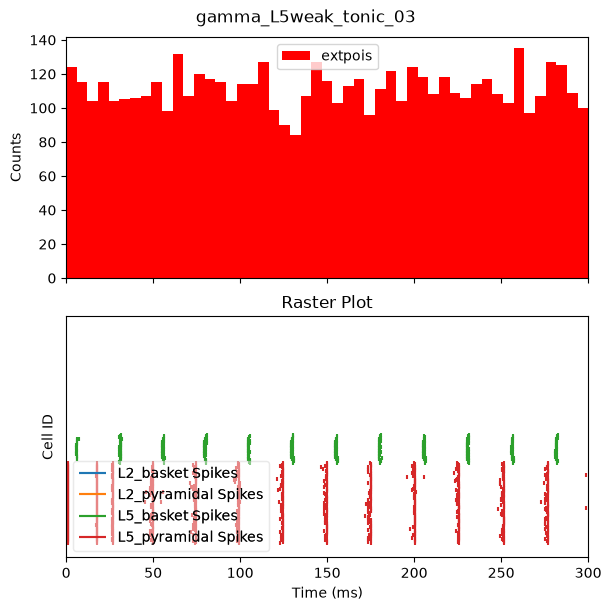

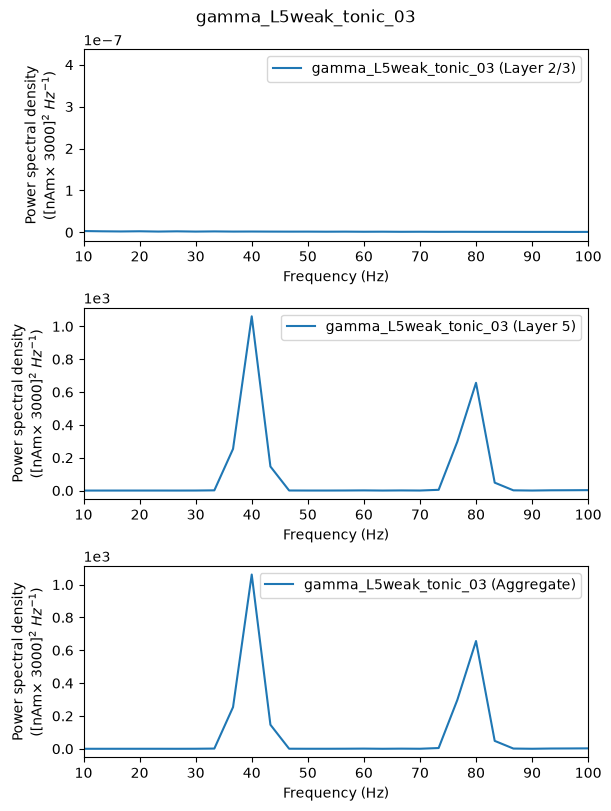

In [19]:
dpl_weak_conn = run_simulation(net_weak_conn)

plot_drive_and_dipole(net_weak_conn, dpl_weak_conn, 'gamma_L5weak_tonic_03')
plot_drive_and_spikes(net_weak_conn, 'gamma_L5weak_tonic_03')
plot_psd_by_layer(dpl_weak_conn, 'gamma_L5weak_tonic_03')

### 8.5 Removing the Inhibitory Connections

Next, we'll explore the importance of the inhibitory connections in setting gamma rhythmicity more directly. In the GUI, this section begins by restoring the `L5_pyramidal` to `L5_basket` weight and deleting the `Tonic1` drive, so that the network returns to the state it was in for `gamma_L5weak_only`. With the API, we get this for free by simply re-loading the configuration file.

We then remove the `L5_basket` to `L5_basket` connection by setting its $GABA_A$ weight from `0.0075` to `0`, so that the basket cells no longer inhibit one another.

In [20]:
net_no_inh = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_L5weak_only.json')

conn_indices = pick_connection(net_no_inh, src_gids='L5_basket',
                               target_gids='L5_basket', receptor='gabaa')
for idx in conn_indices:
    print('original weight:', net_no_inh.connectivity[idx]['nc_dict']['A_weight'])
    net_no_inh.connectivity[idx]['nc_dict']['A_weight'] = 0.
    print('new weight:     ', net_no_inh.connectivity[idx]['nc_dict']['A_weight'])

original weight: 0.0075
new weight:      0.0


Upon simulation, notice that the rhythm is still present but is much less regular and much more noisy compared to Section 8.1 above. This lack of regularity is due to the fact that removing the inhibitory-to-inhibitory connections causes the inhibition to be less synchronous and noisier, which in turn causes the overall PING rhythm to become noisier. Indeed, the spectrogram shows that the gamma oscillation itself becomes unstable and gradually changes in frequency.

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

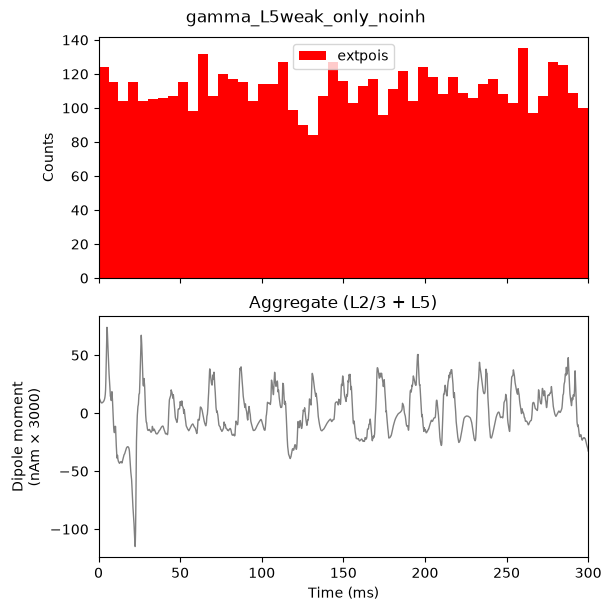

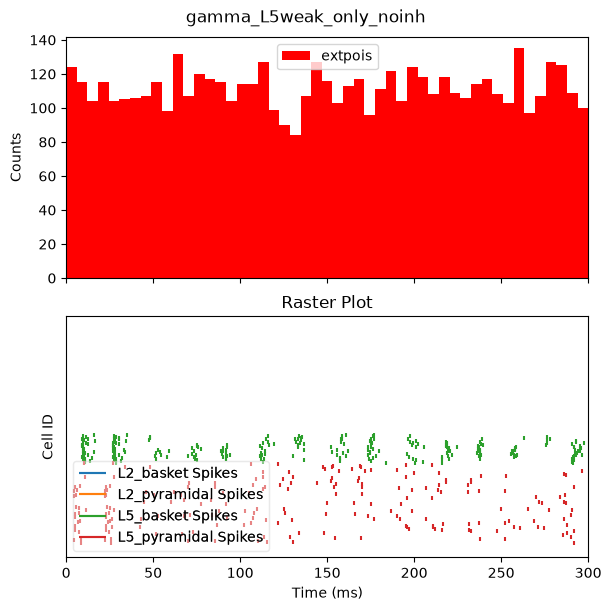

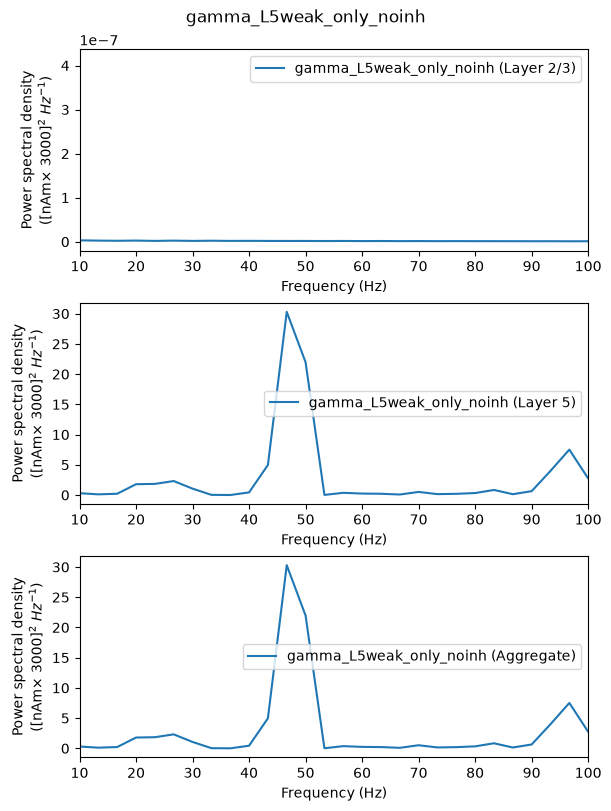

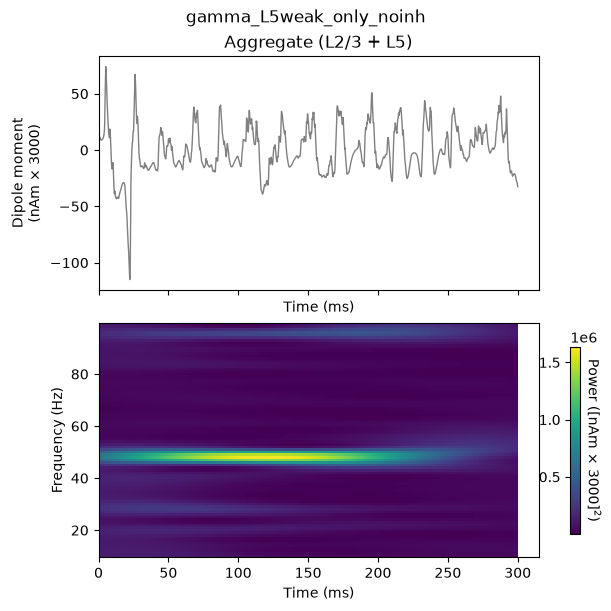

In [21]:
dpl_no_inh = run_simulation(net_no_inh)

plot_drive_and_dipole(net_no_inh, dpl_no_inh, 'gamma_L5weak_only_noinh')
plot_drive_and_spikes(net_no_inh, 'gamma_L5weak_only_noinh')
plot_psd_by_layer(dpl_no_inh, 'gamma_L5weak_only_noinh')
plot_dipole_and_spectrogram(dpl_no_inh, 'gamma_L5weak_only_noinh')

### 8.6 Reducing the GABAA Decay Time

Lastly, we'll show that the time constant of inhibitory decay is an essential parameter controlling the frequency of the PING rhythm. Starting again from the unmodified Layer-5-only network (which restores the `L5_basket` to `L5_basket` connection), we decrease the $GABA_A$ decay time of the L5 pyramidal cells from `5` ms to `2` ms. In the GUI, this is set in the `Cell parameters` sub-tab of the `Network` tab, under `Synapses` for the `L5 Pyramidal` cell type; with the API, this is the `tau2` value of the `gabaa` synapse of the cell type.

In [22]:
net_gabaa = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_L5weak_only.json')

l5_pyr_synapses = net_gabaa.cell_types['L5_pyramidal']['cell_object'].synapses
print('original GABA-A decay time (tau2):', l5_pyr_synapses['gabaa']['tau2'], 'ms')
l5_pyr_synapses['gabaa']['tau2'] = 2.
print('new GABA-A decay time (tau2):     ', l5_pyr_synapses['gabaa']['tau2'], 'ms')

original GABA-A decay time (tau2): 5.0 ms
new GABA-A decay time (tau2):      2.0 ms


Notice that the rhythm is now faster, at ~60 Hz. As illustrated in the spiking activity, the faster decay of inhibition allows the pyramidal neurons to recover more quickly from the inhibition and respond to the Poisson drive, resulting in a faster network oscillation.

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

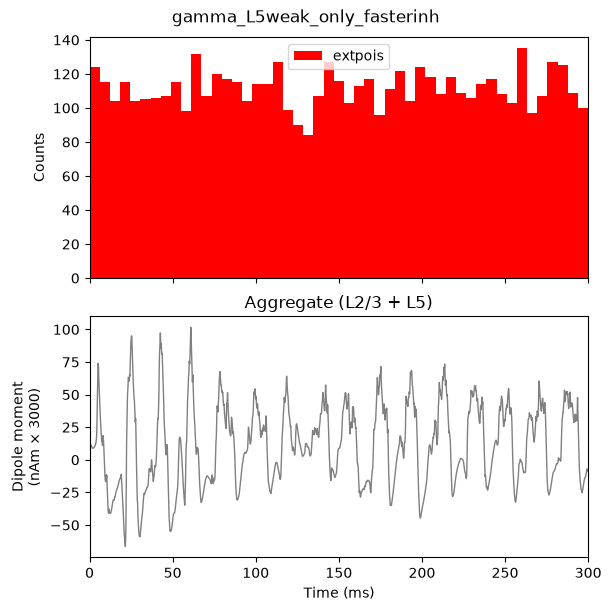

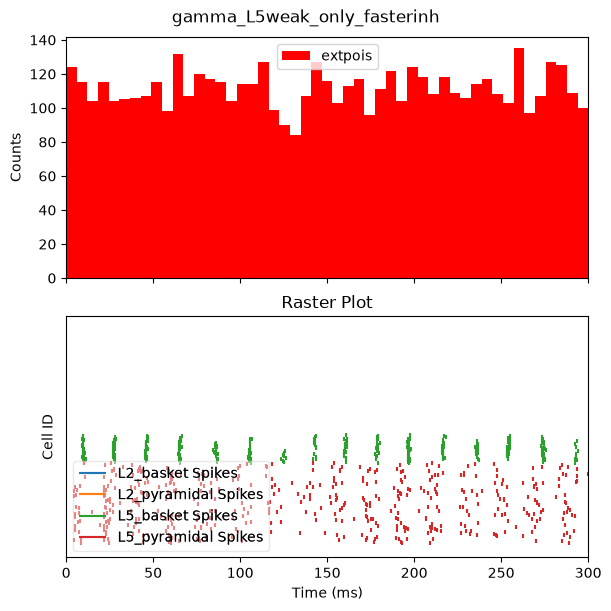

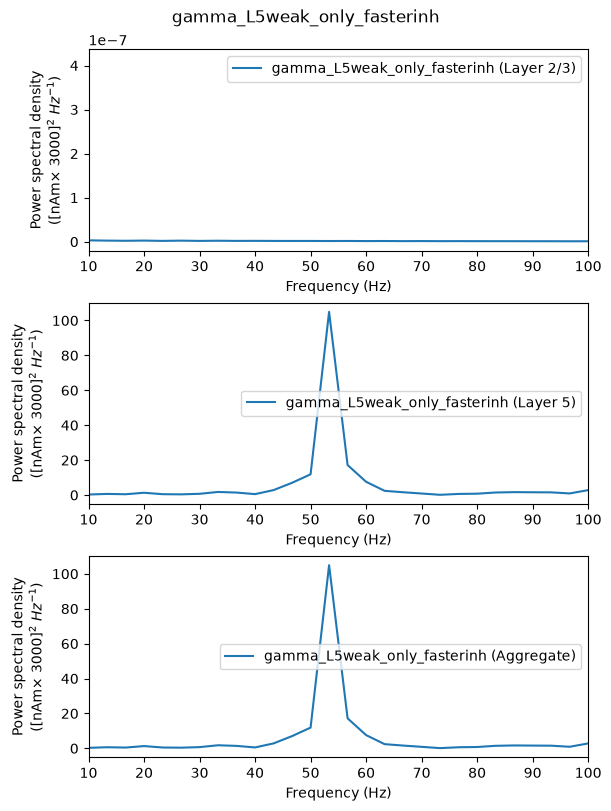

In [23]:
dpl_gabaa = run_simulation(net_gabaa)

plot_drive_and_dipole(net_gabaa, dpl_gabaa, 'gamma_L5weak_only_fasterinh')
plot_drive_and_spikes(net_gabaa, 'gamma_L5weak_only_fasterinh')
plot_psd_by_layer(dpl_gabaa, 'gamma_L5weak_only_fasterinh')

### 8.7 Exercises for Further Exploration

- How else might the excitability of the cells be adjusted? What happens to the network dynamics? Can you make the oscillation faster or slower?

- How else might the synaptic connections in the network be adjusted to impact gamma? What happens to the network dynamics? Can you make the oscillation faster or slower?

- Gamma rhythms can be created in networks where the pyramidal neurons do not fire on their own but their activity is still regulated by interneuron firing (interneuron mediated gamma or "ING"). Can you adjust parameters to create such an oscillation in the network?

## 9. "Strong" Gamma Can Arise from Tonic Inputs to Pyramidal Neurons

**Keep in mind that Layer 2/3 and Layer 5 are not synaptically connected to each other in this simulation, or any other in this Tutorial.**

The next exercise involves setting up a PING rhythm in both Layer 2/3 and Layer 5 by providing only *tonic* inputs to the pyramidal neurons, as opposed to the stochastic *Poisson* inputs (or Poisson + tonic inputs) described above. To do so, we apply a constant depolarizing current injection to the soma of the neurons, representative of a "tonic input".

We load the `gamma_L5ping_L2ping.json` configuration, which contains **no** external drives, and then add a tonic bias of 4 nA to the Layer 2/3 pyramidal cells and 6 nA to the Layer 5 pyramidal cells. Note that we do **not** add any tonic input to the inhibitory cells.

In [24]:
# `add_tonic_bias()` accepts a dictionary of cell type -> amplitude, so
# both biases can be added in a single call.
net_ping = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_L5ping_L2ping.json')
print('external drives:', list(net_ping.external_drives.keys()))

net_ping.add_tonic_bias(amplitude={'L2_pyramidal': 4., 'L5_pyramidal': 6.})

external drives: []


In this simulation, there are no spiking inputs provided to the model; instead, a current clamp provides a constant depolarizing current to the pyramidal neuron somas, causing the cells to fire. As we will see, this firing initiates the PING rhythm through mechanisms similar to those described above. In contrast to the Poisson drive, the constant depolarization to the pyramidal neurons creates higher excitability, causing more synchronous firing. In turn, this causes the interneurons to fire synchronously, producing a higher amplitude gamma oscillation.

In the results below, the dipole displays sharp downward deflections (compare to the "weak" PING of Section 6 above). This is caused by the strong synchronous inhibition onto the pyramidal neuron somas, which pulls current flow down the dendrites. This PING rhythm has less variability than the earlier simulations, and would thus be considered **"strong" PING** rather than "weak" PING.

Taken together, the PSD and spectrogram illustrate that the dipole signal contains strong oscillatory components in the gamma range (approximately ~45 Hz) in the net dipole, which is being driven by the strong Layer 5 activity. Layer 2/3 is oscillating at a higher frequency with a lower amplitude — note the scaling of the y-axes in the PSD.

The higher-frequency activity in Layer 5 (approximately ~85 Hz) comes from the sharp deflections in the dipole waveform along with their small-amplitude peak. Together, these parts of the signal create high power at ~85 Hz in the frequency domain. These deflections are driven by the strong depolarizing current on the pyramidal neurons, which causes their voltage to rise quickly, even before the inhibitory neurons fire.

A closer look at the spiking activity reveals the mechanisms creating these waveform shapes. The PING mechanism is seen in each layer where the pyramidal neurons fire, causing the inhibitory neurons to fire, which consequently stop the pyramidal neurons from firing until their excitation outweighs the inhibition. Notice that the firing rate of the Layer 2/3 pyramidal and basket neurons is faster than that of the Layer 5 neurons. This is because, although the Layer 2/3 pyramidal neurons receive a lower current injection, they have shorter dendrites, and therefore the current flow up and down the dendrites is faster. Further, the Layer 2/3 pyramidal neurons have lower spiking thresholds due to their intrinsic properties.

As an exercise, play with the current injection amplitude provided to the different neurons to see how it affects the generated rhythm.

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

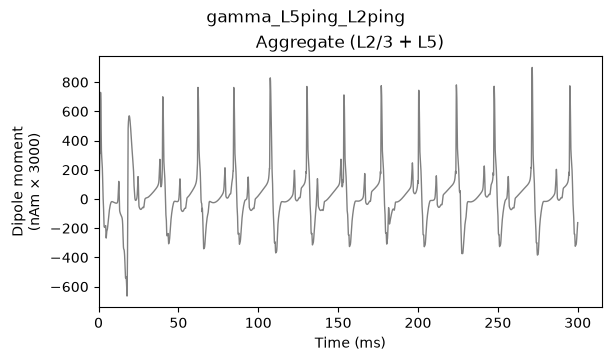

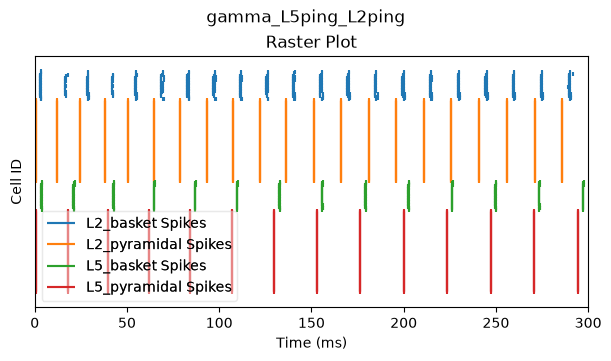

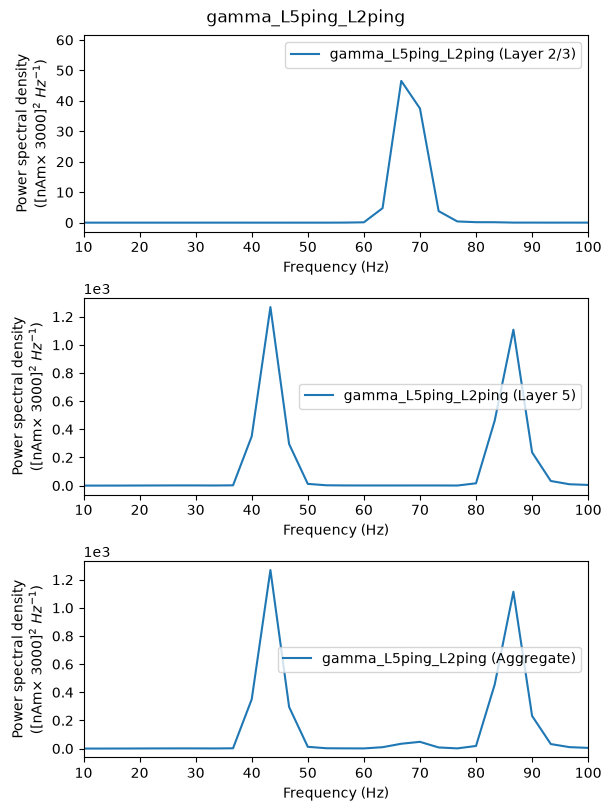

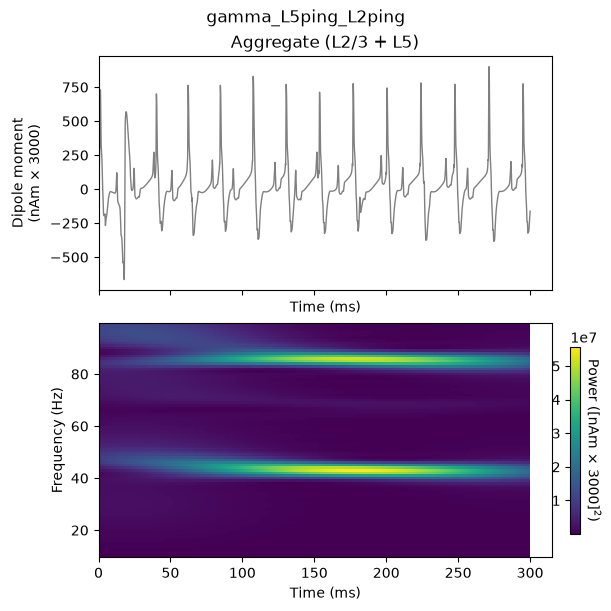

In [25]:
dpl_ping = run_simulation(net_ping)

plot_drive_and_dipole(net_ping, dpl_ping, 'gamma_L5ping_L2ping')
plot_drive_and_spikes(net_ping, 'gamma_L5ping_L2ping')
plot_psd_by_layer(dpl_ping, 'gamma_L5ping_L2ping')
plot_dipole_and_spectrogram(dpl_ping, 'gamma_L5ping_L2ping')

## 10. Gamma Can Emerge from Rhythmic Subthreshold Synaptic Inputs to Pyramidal Neurons

In the next example, we apply 50 Hz rhythmic synaptic inputs through proximal and distal projection patterns to produce gamma oscillations similar to those shown in Figure 8A of (Lee and Jones, 2013).

In this simulation, the strength of the input is set so that the cells remain subthreshold, while gamma rhythms emerge from subthreshold current flow in the pyramidal neuron dendrites. This is fundamentally different from how the PING mechanisms described above are generated from local spiking interactions.

The `gamma_rhythmic_drive.json` configuration contains two drives, `bursty1` (proximal) and `bursty2` (distal). The proximal and distal inputs start at 50.0 and 55.0 ms respectively, and are slightly out of phase. This phase mis-alignment allows the synaptic inputs to effectively push current flow up the dendrites, followed 5 ms later by current flow down the dendrites. The input frequency (`burst_rate`) for both proximal and distal inputs is 50 Hz, representing "bursts" of excitatory synaptic input, so the driving burst has an inter-burst-interval of 20 ms (that is, `1/(50 Hz)`), with minimal noise within each driving burst (`burst_std` of 2.5 Hz).

Note also that the amplitude of the inputs, which are **only provided to the Layer 5 pyramidal neurons**, is set to a small value of `0.00004` $\mu S$, which produces only subthreshold responses.

We also need a longer simulation: in the GUI, you would increase `tstop` to `550` ms in the `Simulation` tab.

In [26]:
tstop_rhythmic = 550.0

net_rhythmic = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_rhythmic_drive.json')

# Inspect the parameters of the two bursty drives
for drive_name, drive in net_rhythmic.external_drives.items():
    print(drive_name, '(%s):' % drive['location'], drive['dynamics'])

bursty1 (proximal): {'tstart': 50.0, 'tstart_std': 0.0, 'tstop': 550.0, 'burst_rate': 50.0, 'burst_std': 2.5, 'numspikes': 1, 'spike_isi': 10}
bursty2 (distal): {'tstart': 55.0, 'tstart_std': 0.0, 'tstop': 550.0, 'burst_rate': 50.0, 'burst_std': 2.5, 'numspikes': 1, 'spike_isi': 10}


In the results below, the net dipole signal shows a clear gamma rhythm at ~50 Hz, produced by the Layer 5 pyramidal neurons. Our spike rastergram is completely empty, unlike before, because these are *sub-threshold* oscillations. Note that here, the Layer 2/3 pyramidal neurons are not receiving any drive, and therefore do not contribute to the dipole current. Also note that the waveform shape in this simulation is distinct from the previous examples in both the total magnitude of the dipole moment and in the lack of sharp deflections, which previously were produced by neuronal firing and strong somatic inhibition during PING.

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

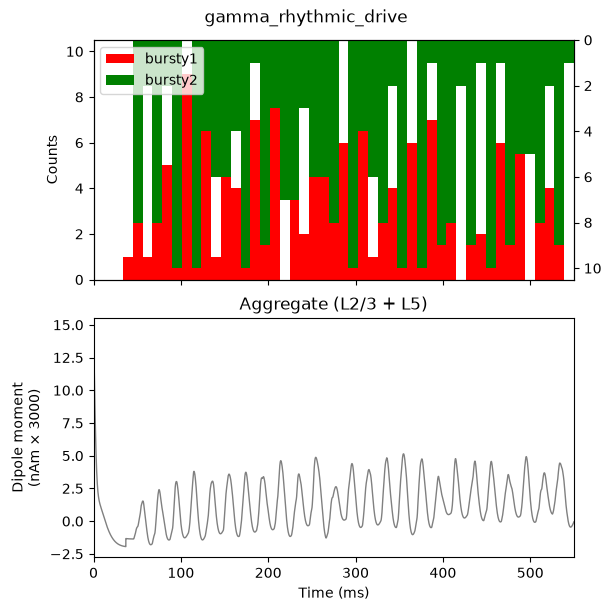

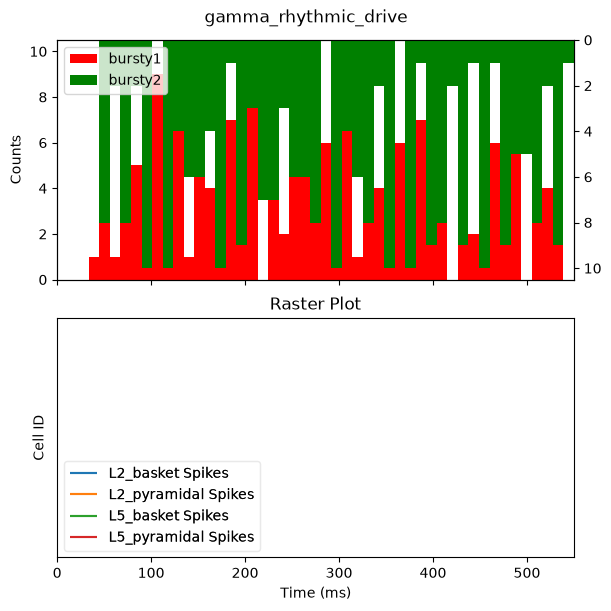

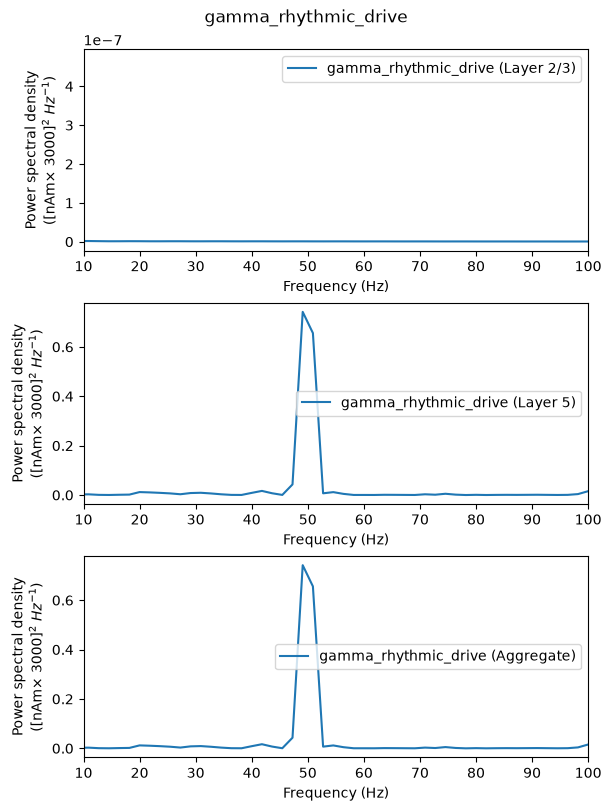

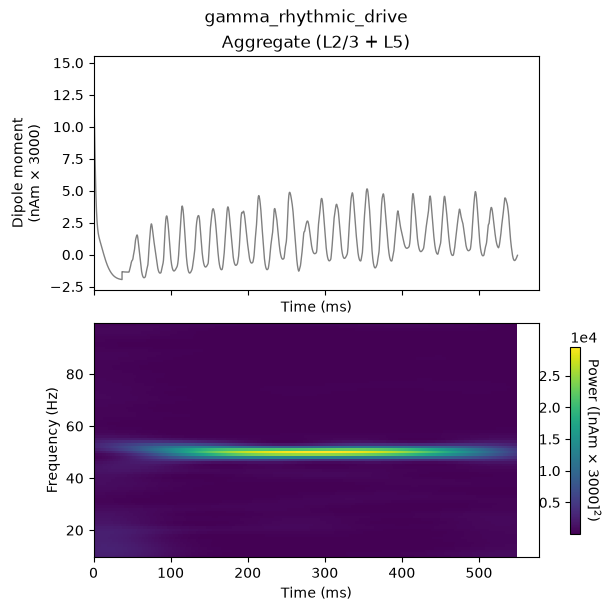

In [27]:
dpl_rhythmic = run_simulation(net_rhythmic, tstop=tstop_rhythmic)

plot_drive_and_dipole(net_rhythmic, dpl_rhythmic, 'gamma_rhythmic_drive')
plot_drive_and_spikes(net_rhythmic, 'gamma_rhythmic_drive')
plot_psd_by_layer(dpl_rhythmic, 'gamma_rhythmic_drive')
plot_dipole_and_spectrogram(dpl_rhythmic, 'gamma_rhythmic_drive')

### 10.1 Adding Noise to Gamma Generated through Rhythmic Subthreshold Synaptic Inputs

In the final simulation of this section, we add more noise to the 50 Hz rhythmic drive by changing the `burst_std` of each of the two drives from `2.5` to `5` Hz. This is the `Burst std dev (Hz)` parameter in the GUI.


In [28]:
# -----------------------------------------------------------------------
# 10.1 Adding noise to the rhythmic subthreshold drive
#
# Increase the `burst_std` of both bursty drives from 2.5 Hz to 5 Hz. This
# adds variability to the timing of the burst of synaptic drive that each
# input provides, and hence adds more "noise" to the network.
#
# Since there are still no spikes, we skip the `Drive-Spikes (2x1)` figure
# here, just as the GUI walkthrough does.
# -----------------------------------------------------------------------
net_noisy = read_network_configuration(
    local_gamma_network_files_directory / 'gamma_rhythmic_drive.json')

for drive_name in ['bursty1', 'bursty2']:
    dynamics = net_noisy.external_drives[drive_name]['dynamics']
    print('%s original burst_std: %s Hz' % (drive_name, dynamics['burst_std']))
    dynamics['burst_std'] = 5.
    print('%s new burst_std:      %s Hz' % (drive_name, dynamics['burst_std']))


bursty1 original burst_std: 2.5 Hz
bursty1 new burst_std:      5.0 Hz
bursty2 original burst_std: 2.5 Hz
bursty2 new burst_std:      5.0 Hz


Due to the higher variability in synaptic input timing, there is now more variability in the temporal dynamics and frequency content seen in the dipole signal, which can also be seen in the less-consistent 50 Hz gamma events in the spectrogram. With the added noise, we also observe lower-frequency peaks with relatively high power in the average PSD, though the intermittent gamma events still yield the highest-power peak observed in the PSD.

MPI will run 1 trial(s) sequentially by distributing network neurons over 11 processes.
numprocs=11
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from 

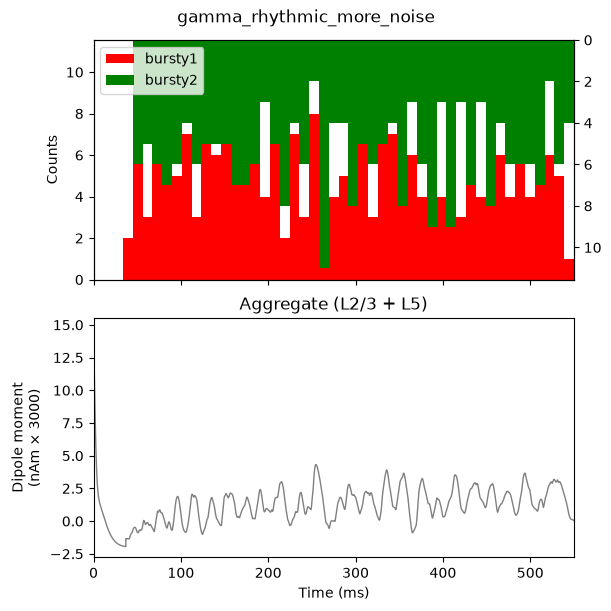

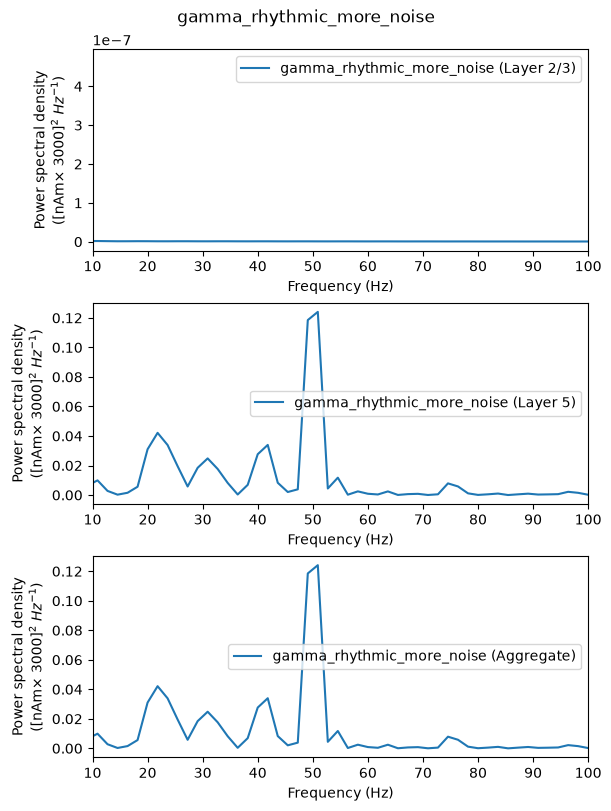

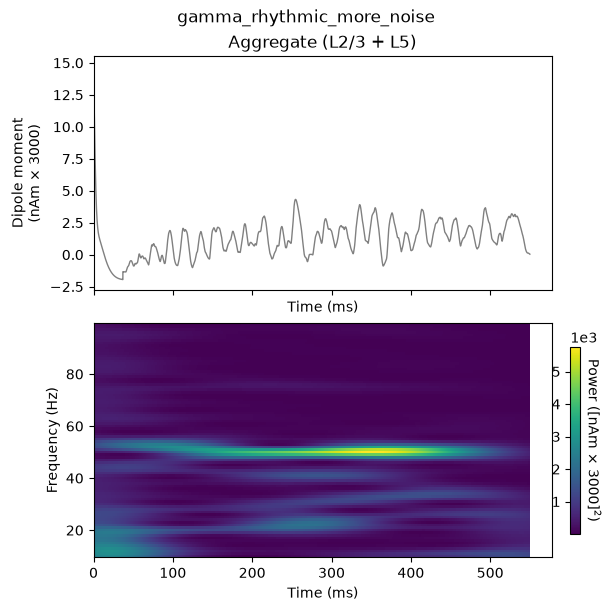

In [29]:
dpl_noisy = run_simulation(net_noisy, tstop=tstop_rhythmic)

plot_drive_and_dipole(net_noisy, dpl_noisy, 'gamma_rhythmic_more_noise')
plot_psd_by_layer(dpl_noisy, 'gamma_rhythmic_more_noise')
plot_dipole_and_spectrogram(dpl_noisy, 'gamma_rhythmic_more_noise')

### 10.2 Exercises for Further Exploration

- Go back to the `gamma_L5weak_L2weak` configuration and add recurrent synaptic connectivity between pyramidal neurons within a layer (e.g., L5 Pyr to L5 Pyr weight = `0.00091e-4`); how does that change the gamma rhythm? What happens as you change the strength of this connection?

- Add connectivity between Layer 2/3 and Layer 5. Is gamma rhythmicity retained? Under what circumstances might gamma persist?

## 11. Have Fun Exploring your Own Data!

We have **not** observed strong gamma activity in our primary somatosensory cortex dipole data, and as such have not provided an example data set to compare simulation results to. However, simulation results can be compared to recorded data, as described in the ERP and Alpha/Beta tutorials. Follow the steps above using your data and make parameter adjustments based on your own hypotheses.

## References

Buzsáki, György, and Xiao-Jing Wang. 2012. “Mechanisms of Gamma Oscillations.” Annual Review of Neuroscience 35 (1): 203–25. [https://doi.org/10.1146/annurev-neuro-062111-150444](https://doi.org/10.1146/annurev-neuro-062111-150444).

Cardin, Jessica A., Marie Carlén, Konstantinos Meletis, Ulf Knoblich, Feng Zhang, Karl Deisseroth, Li-Huei Tsai, and Christopher I. Moore. 2009. “Driving Fast-Spiking Cells Induces Gamma Rhythm and Controls Sensory Responses.” Nature 459 (7247): 663–67. [https://doi.org/10.1038/nature08002](https://doi.org/10.1038/nature08002).

Lee, Shane, and Stephanie R. Jones. 2013. “Distinguishing Mechanisms of Gamma Frequency Oscillations in Human Current Source Signals Using a Computational Model of a Laminar Neocortical Network.” Frontiers in Human Neuroscience 7 (December). [https://doi.org/10.3389/fnhum.2013.00869](https://doi.org/10.3389/fnhum.2013.00869).

Vierling-Claassen, Dorea, Jessica Cardin, Christopher I. Moore, and Stephanie R. Jones. 2010. “Computational Modeling of Distinct Neocortical Oscillations Driven by Cell-Type Selective Optogenetic Drive: Separable Resonant Circuits Controlled by Low-Threshold Spiking and Fast-Spiking Interneurons.” Frontiers in Human Neuroscience 4 (November). [https://doi.org/10.3389/fnhum.2010.00198](https://doi.org/10.3389/fnhum.2010.00198). 